# Bài tập 1 — Hiểu dữ liệu, chọn dữ liệu và tiền xử lý
### Môn Khai phá dữ liệu — Trường Đại học Giao thông Vận tải TP.HCM
### Nhóm: ......... | Lớp: ......... | Ngày: .........

**Ba bộ dữ liệu khảo sát:**
1. **Bộ 1 — Olist Brazilian E-Commerce** (thương mại điện tử)
2. **Bộ 2 — Inside Airbnb Listings** (cho thuê lưu trú)
3. **Bộ 3 — US Accidents (2016–2023)** (tai nạn giao thông)

Notebook này thực hiện:
- Mục 3.2: khảo sát nguồn/quy mô, từ điển dữ liệu, điều tra tri thức lĩnh vực, lập luận khả năng khai phá cho từng bộ.
- Mục 3.3: điều tra tiền xử lý (nhiễu/ngoại lai, giá trị thiếu, thêm/xóa/biến đổi thuộc tính).
- Mục 2.1: ma trận bộ dữ liệu × kỹ thuật tổng hợp cuối notebook.

> **Lưu ý:** Notebook chỉ là **khung sườn** với code mẫu và các hàm khảo sát dùng lại được (reusable). Nhóm cần: (1) tải dữ liệu thật vào thư mục `data/raw/`, (2) chạy lại toàn bộ để lấy số liệu thật thay cho placeholder, (3) tự viết phần nhận xét/diễn giải bằng lời của nhóm ở các ô markdown đánh dấu `✍️ TODO`.


In [1]:
# ==== Thiết lập chung ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

RAW_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'


## Hàm tiện ích dùng chung cho cả 3 bộ dữ liệu

Các hàm dưới đây được viết một lần và tái sử dụng cho cả 3 bộ, tránh lặp code.

In [2]:
def data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Sinh bảng từ điển dữ liệu tự động: kiểu, số giá trị duy nhất, tỉ lệ thiếu, min/max sơ bộ.
    Nhóm dùng bảng này làm điểm khởi đầu, sau đó bổ sung cột 'Ý nghĩa' và 'Thang đo' bằng tay.
    """
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            'thuoc_tinh': col,
            'kieu_du_lieu': str(s.dtype),
            'so_gia_tri_duy_nhat': s.nunique(dropna=True),
            'ti_le_thieu_%': round(s.isna().mean() * 100, 2),
            'gia_tri_min': s.min() if pd.api.types.is_numeric_dtype(s) else None,
            'gia_tri_max': s.max() if pd.api.types.is_numeric_dtype(s) else None,
            'vi_du': s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows)


def missing_value_report(df: pd.DataFrame, threshold: float = 0.0) -> pd.DataFrame:
    """Báo cáo tỉ lệ thiếu theo từng cột, sắp xếp giảm dần. threshold: chỉ hiện cột có tỉ lệ thiếu > threshold (%)."""
    miss = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
    miss = miss[miss > threshold]
    return miss.to_frame('ti_le_thieu_%')


def outlier_iqr_report(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Đếm số ngoại lai theo phương pháp IQR cho từng cột số được chỉ định."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((s < lower) | (s > upper)).sum()
        rows.append({
            'thuoc_tinh': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'nguong_duoi': lower, 'nguong_tren': upper,
            'so_ngoai_lai': n_outliers,
            'ti_le_ngoai_lai_%': round(n_outliers / len(s) * 100, 2) if len(s) else np.nan,
        })
    return pd.DataFrame(rows)


def plot_boxplots(df: pd.DataFrame, cols: list, ncols: int = 3, figsize_scale: float = 4):
    """Vẽ boxplot cho danh sách cột số để trực quan hóa ngoại lai."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        sns.boxplot(y=df[col].dropna(), ax=axes[i])
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


---
# BỘ 1: Olist Brazilian E-Commerce

**Nguồn:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
**Quy mô kỳ vọng:** ~99.441 đơn hàng, 54 thuộc tính sau khi gộp 9 bảng
**Giấy phép:** dữ liệu thương mại đã ẩn danh, dùng cho học thuật/nghiên cứu

## 1.1 Tải dữ liệu và gộp bảng (join)

In [3]:
# Đặt các file gốc trong data/raw/olist/
olist_dir = f'{RAW_DIR}/olist'

customers   = pd.read_csv(f'{olist_dir}/olist_customers_dataset.csv')
orders      = pd.read_csv(f'{olist_dir}/olist_orders_dataset.csv')
order_items = pd.read_csv(f'{olist_dir}/olist_order_items_dataset.csv')
payments    = pd.read_csv(f'{olist_dir}/olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{olist_dir}/olist_order_reviews_dataset.csv')
products    = pd.read_csv(f'{olist_dir}/olist_products_dataset.csv')
sellers     = pd.read_csv(f'{olist_dir}/olist_sellers_dataset.csv')
geoloc      = pd.read_csv(f'{olist_dir}/olist_geolocation_dataset.csv')
cat_trans   = pd.read_csv(f'{olist_dir}/product_category_name_translation.csv')

print('orders:', orders.shape)
print('order_items:', order_items.shape)
print('customers:', customers.shape)


orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)


In [4]:
# Gộp thành 1 bảng phân tích: mỗi dòng = 1 item trong 1 đơn hàng
olist_df = (
    order_items
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
    .merge(cat_trans, on='product_category_name', how='left')
    .merge(payments, on='order_id', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
)

print('Số dòng x số cột sau khi join:', olist_df.shape)
olist_df.head()


Số dòng x số cột sau khi join: (118310, 35)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277,volta redonda,SP,cool_stuff,1.0,credit_card,2.0,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471,sao paulo,SP,pet_shop,1.0,credit_card,3.0,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564,borda da mata,MG,furniture_decor,1.0,credit_card,5.0,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,14403,franca,SP,perfumery,1.0,credit_card,2.0,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,87900,loanda,PR,garden_tools,1.0,credit_card,3.0,218.04,5.0


## 1.2 Từ điển dữ liệu (tự động sinh — bổ sung cột Ý nghĩa/Thang đo bằng tay)

In [5]:
olist_dict = data_dictionary(olist_df)
olist_dict
# ✍️ TODO: xuất bảng này ra file/paste vào báo cáo, bổ sung cột 'Ý nghĩa' và 'Thang đo' cho từng thuộc tính.


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du
0,order_id,str,98666,0.00,NaN,NaN,00010242fe8c5a6d1ba2dd792cb16214
1,order_item_id,int64,21,0.00,1.00,21.00,1
2,product_id,str,32951,0.00,NaN,NaN,4244733e06e7ecb4970a6e2683c13e61
3,seller_id,str,3095,0.00,NaN,NaN,48436dade18ac8b2bce089ec2a041202
4,shipping_limit_date,str,93318,0.00,NaN,NaN,2017-09-19 09:45:35
5,price,float64,5968,0.00,0.85,6735.00,58.9
6,freight_value,float64,6999,0.00,0.00,409.68,13.29
7,customer_id,str,98666,0.00,NaN,NaN,3ce436f183e68e07877b285a838db11a
8,order_status,str,7,0.00,NaN,NaN,delivered
9,order_purchase_timestamp,str,98112,0.00,NaN,NaN,2017-09-13 08:59:02


## 1.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

✍️ **TODO (nhóm viết):** mô tả bối cảnh nghiệp vụ (Olist là gì, vòng đời một đơn hàng ra sao), liên hệ giữa các thuộc tính.
Xem bản nháp lập luận ở tài liệu "Đề xuất 3 bộ dữ liệu" đã có — viết lại bằng hiểu biết thực tế sau khi khảo sát dữ liệu này.

**Kiểm chứng nhanh bằng code:**

review_score
1.0    14857
2.0     4085
3.0     9840
4.0    22286
5.0    66264
NaN      978
Name: count, dtype: int64


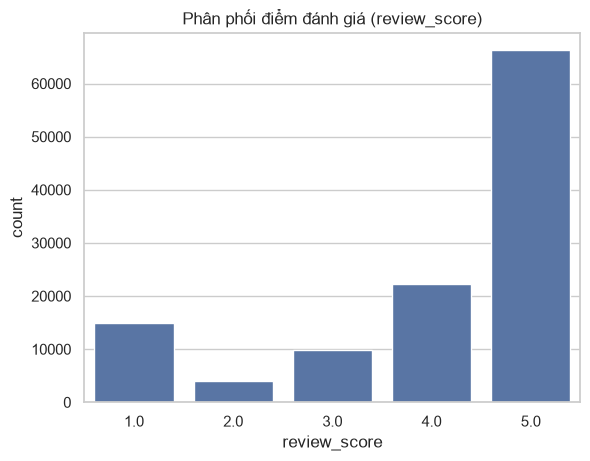

In [6]:
# Kiểm tra khả năng PHÂN LỚP: phân phối review_score (biến mục tiêu tiềm năng)
print(olist_df['review_score'].value_counts(dropna=False).sort_index())
sns.countplot(x='review_score', data=olist_df)
plt.title('Phân phối điểm đánh giá (review_score)')
plt.show()


In [7]:
# Kiểm tra khả năng LUẬT KẾT HỢP: số lượng ngành hàng (product_category_name_english) khác nhau
# trên mỗi đơn hàng -> xác nhận có tồn tại cấu trúc "giỏ hàng" đa mục hay không
basket_size = olist_df.groupby('order_id')['product_category_name_english'].nunique()
print(basket_size.describe())
print('Tỉ lệ đơn có từ 2 ngành hàng khác nhau trở lên: %.2f%%' % (
    (basket_size >= 2).mean() * 100
))


count    98666.000000
mean         0.993220
std          0.148523
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: product_category_name_english, dtype: float64
Tỉ lệ đơn có từ 2 ngành hàng khác nhau trở lên: 0.74%


In [8]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng số dùng cho RFM khách hàng
rfm_check = olist_df.groupby('customer_unique_id').agg(
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum'),
)
rfm_check.describe()


,frequency,monetary
count,95420.000000,95420.000000
mean,1.034018,213.968167
std,0.211234,645.757464
min,1.000000,0.000000
25%,1.000000,63.990000
50%,1.000000,113.330000
75%,1.000000,203.300000
max,16.000000,109312.640000


## 1.4 Kỹ thuật đề xuất trên Bộ 1

→ **Luật kết hợp** (ngành hàng mua cùng nhau) và **Gom cụm** (phân khúc khách hàng theo RFM).

## 1.5 Điều tra tiền xử lý (Mục 3.3)

### 1.5.1 Giá trị thiếu

In [9]:
missing_value_report(olist_df, threshold=0)


,ti_le_thieu_%
order_delivered_customer_date,2.19
product_category_name_english,1.47
product_name_lenght,1.44
product_description_lenght,1.44
product_photos_qty,1.44
product_category_name,1.44
order_delivered_carrier_date,1.06
review_score,0.83
product_weight_g,0.02
product_height_cm,0.02


✍️ TODO: nhận định cơ chế thiếu cho từng cột có tỉ lệ cao (xem bảng ở tài liệu đề xuất làm gợi ý), quyết định xử lý.

### 1.5.2 Nhiễu và ngoại lai

In [10]:
numeric_cols_olist = ['price', 'freight_value', 'payment_value', 'product_weight_g']
outlier_iqr_report(olist_df, numeric_cols_olist)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,price,39.90,134.90,95.00,-102.600,277.400,8867,7.49
1,freight_value,13.08,21.18,8.10,0.930,33.330,12740,10.77
2,payment_value,60.85,189.26,128.41,-131.765,381.875,9549,8.07
3,product_weight_g,300.00,1800.00,1500.00,-1950.000,4050.000,16696,14.11


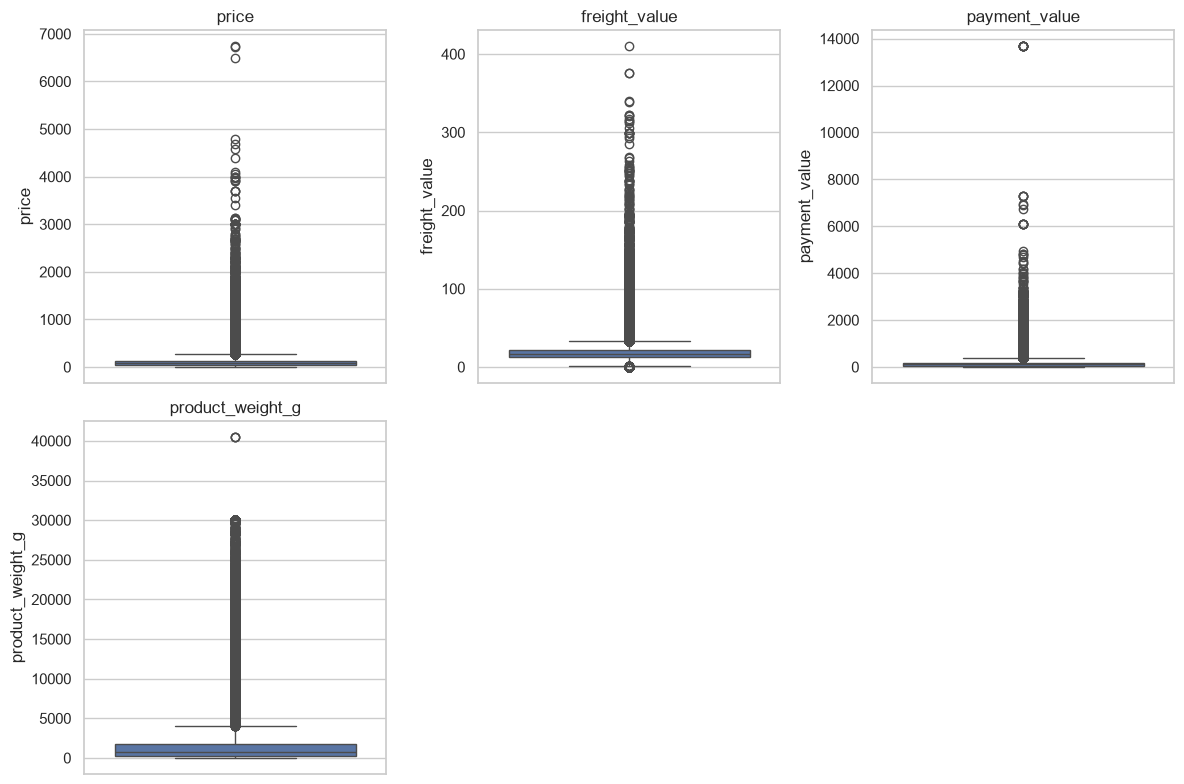

In [11]:
plot_boxplots(olist_df, numeric_cols_olist)


In [12]:
# Kiểm tra ràng buộc logic thời gian: ngày giao phải sau ngày đặt
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

logic_violation = orders[
    orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
]
print('Số đơn vi phạm ràng buộc logic thời gian (giao trước khi đặt):', len(logic_violation))


Số đơn vi phạm ràng buộc logic thời gian (giao trước khi đặt): 0


### 1.5.3 Thêm / xóa / biến đổi thuộc tính

In [13]:
# Thêm thuộc tính dẫn xuất: độ trễ giao hàng (ngày) -> dùng làm nhãn phân lớp dự phòng
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days
orders['is_late'] = orders['delivery_delay_days'] > 0

print(orders['is_late'].value_counts(dropna=False))


is_late
False    92906
True      6535
Name: count, dtype: int64


In [14]:
# Thêm đặc trưng RFM đầy đủ cho gom cụm khách hàng
snapshot_date = orders['order_purchase_timestamp'].max()

rfm = (
    orders.merge(customers, on='customer_id')
    .merge(payments, on='order_id')
    .groupby('customer_unique_id')
    .agg(
        recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum'),
    )
)
rfm.head()


,recency_days,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
0000f46a3911fa3c0805444483337064,585,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [15]:
# Lưu dữ liệu đã tiền xử lý (mẫu)
import os
os.makedirs(f'{PROCESSED_DIR}/olist', exist_ok=True)
olist_df.to_csv(f'{PROCESSED_DIR}/olist/olist_merged_raw.csv', index=False)
rfm.to_csv(f'{PROCESSED_DIR}/olist/olist_customer_rfm.csv')
print('Đã lưu file tiền xử lý Bộ 1.')


Đã lưu file tiền xử lý Bộ 1.


---
# BỘ 2: Inside Airbnb — Detailed Listings

**Nguồn:** http://insideairbnb.com/get-the-data/ (chọn 1 thành phố ≥ 25.000 listing)
**Quy mô kỳ vọng:** 20.000–90.000+ dòng, 74 cột
**Giấy phép:** công khai cho nghiên cứu phi thương mại

## 2.1 Tải dữ liệu

In [16]:
airbnb_path = f'{RAW_DIR}/airbnb/listings.csv'
airbnb_df = pd.read_csv(airbnb_path)
print('Kích thước:', airbnb_df.shape)
airbnb_df.head()


Kích thước: (30259, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,https://www.airbnb.com/users/show/2787,1.462506e+18,https://www.airbnb.com/users/profile/146250632...,John,NaN,17.0,9.0,15.0,5.0,"New York, NY",Educated professional living in Brooklyn. I l...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,5.0,NaN,NaN,t,t,NaN,Kensington,Brooklyn,40.645937,-73.972164,Private room in condo,Private room,2,1.0,1 shared bath,1.0,2.0,"[""Bed linens"", ""Hot water"", ""Exterior security...",$113.97,2026-07-11,2026-08-10,3419.19,113.97,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",30.0,730.0,30.0,30.0,730.0,730.0,30.0,730.0,NaN,t,4,34,64,339,2026-06-15,10,1,1,174,0,60,6838.0,2015-12-04,2026-05-28,4.80,4.67,4.90,4.89,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,1.462507e+18,https://www.airbnb.com/users/profile/146250678...,Allen,NaN,17.0,1.0,15.0,5.0,"New York, NY",We love to travel. When we travel we like to s...,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/users/15991/profile...,NaN,1.0,NaN,NaN,t,t,NaN,Williamsburg,Brooklyn,40.709350,-73.953420,Entire rental unit,Entire home/apt,3,1.0,1 bath,2.0,1.0,"[""Bed linens"", ""Hot water"", ""Fire extinguisher...",$117.27,2026-12-20,2027-01-19,3518.00,117.27,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",30.0,240.0,30.0,30.0,240.0,240.0,30.0,240.0,NaN,t,1,1,15,191,2026-06-14,198,3,0,27,4,180,21109.0,2009-05-25,2026-04-23,4.60,4.60,4.85,4.85,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,https://www.airbnb.com/users/show/16104,1.462507e+18,https://www.airbnb.com/users/profile/146250678...,Kae,NaN,17.0,1.0,15.0,5.0,"New York, NY",A former life in fashion and wellness h

In [17]:
# ---- Ô CHẨN ĐOÁN: kiểm tra file có đúng bản 'detailed listings' không ----
print('Số dòng x số cột:', airbnb_df.shape)
print('Danh sách cột:')
print(airbnb_df.columns.tolist())

REQUIRED_COLS = ['host_is_superhost', 'amenities', 'price', 'room_type', 'accommodates']
missing_required = [c for c in REQUIRED_COLS if c not in airbnb_df.columns]
if missing_required:
    print()
    print('⚠️  CẢNH BÁO: thiếu các cột bắt buộc:', missing_required)
    print('    -> Nhiều khả năng bạn đang dùng file "listings_summary.csv" (bản rút gọn ~18 cột)')
    print('    -> Cần tải lại đúng file "listings.csv" (bản DETAILED, ~74 cột) tại:')
    print('       http://insideairbnb.com/get-the-data/ -> mục "Detailed Listings data"')
else:
    print()
    print('✅ Đủ các cột bắt buộc để chạy các bước tiếp theo.')


Số dòng x số cột: (30259, 90)
Danh sách cột:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_pric

## 2.2 Từ điển dữ liệu (tự động sinh)

In [18]:
airbnb_dict = data_dictionary(airbnb_df)
airbnb_dict
# ✍️ TODO: bổ sung cột Ý nghĩa/Thang đo cho toàn bộ 74 thuộc tính khi nộp bài.


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du
0,id,int64,30259,0.00,2.539000e+03,1.707075e+18,2539
1,listing_url,str,30259,0.00,NaN,NaN,https://www.airbnb.com/rooms/2539
2,scrape_id,int64,1,0.00,2.026061e+13,2.026061e+13,20260614073253
3,last_scraped,str,4,0.00,NaN,NaN,2026-06-15
4,source,str,2,0.00,NaN,NaN,city scrape
...,...,...,...,...,...,...,...
85,calculated_host_listings_count,int64,70,0.00,1.000000e+00,9.550000e+02,5
86,calculated_host_listings_count_entire_homes,int64,52,0.00,0.000000e+00,9.550000e+02,0
87,calculated_host_listings_count_private_rooms,int64,40,0.00,0.000000e+00,2.310000e+02,5
88,calculated_host_listings_count_shared_rooms,int64,10,0.00,0.000000e+00,2.200000e+01,0


## 2.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

✍️ **TODO (nhóm viết):** bối cảnh mô hình kinh tế chia sẻ Airbnb, liên hệ giữa giá/vị trí/uy tín host.

**Kiểm chứng nhanh bằng code:**

In [19]:
# Làm sạch sơ bộ cột price để kiểm chứng (chỉ phục vụ khảo sát nhanh)
airbnb_df['price_num'] = (
    airbnb_df['price'].astype(str).str.replace('[$,]', '', regex=True).astype(float)
)

# Kiểm tra khả năng PHÂN LỚP: phân phối host_is_superhost
if 'host_is_superhost' in airbnb_df.columns:
    print(airbnb_df['host_is_superhost'].value_counts(dropna=False))
else:
    print("⚠️ Không tìm thấy cột 'host_is_superhost' — kiểm tra lại ô chẩn đoán phía trên."
          " Có thể tạm dùng biến mục tiêu khác, ví dụ phân khúc giá (price_num).")


host_is_superhost
f      22814
t       7096
NaN      349
Name: count, dtype: int64


In [20]:
# Kiểm tra khả năng LUẬT KẾT HỢP: số tiện nghi trung bình mỗi listing (amenities dạng chuỗi JSON-like)
import ast

def parse_amenities(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except Exception:
        return []

if 'amenities' in airbnb_df.columns:
    airbnb_df['amenities_list'] = airbnb_df['amenities'].apply(parse_amenities)
    airbnb_df['amenity_count'] = airbnb_df['amenities_list'].apply(len)
    print(airbnb_df['amenity_count'].describe())
else:
    print("⚠️ Không tìm thấy cột 'amenities' — kiểm tra lại ô chẩn đoán phía trên.")


count    30259.000000
mean        28.507254
std         14.969106
min          0.000000
25%         16.000000
50%         28.000000
75%         39.000000
max        104.000000
Name: amenity_count, dtype: float64


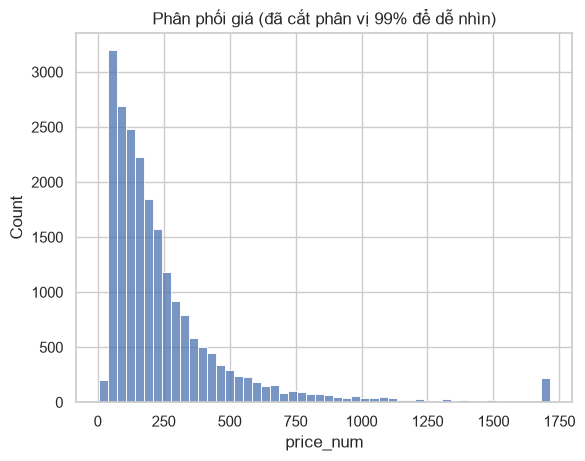

In [21]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng số chính
sns.histplot(airbnb_df['price_num'].clip(upper=airbnb_df['price_num'].quantile(0.99)), bins=50)
plt.title('Phân phối giá (đã cắt phân vị 99% để dễ nhìn)')
plt.show()


## 2.4 Kỹ thuật đề xuất trên Bộ 2

→ **Phân lớp** (Superhost / phân khúc giá) và **Gom cụm** (phân khúc thị trường lưu trú).

## 2.5 Điều tra tiền xử lý (Mục 3.3)

### 2.5.1 Giá trị thiếu

In [22]:
missing_value_report(airbnb_df, threshold=0).head(20)


,ti_le_thieu_%
neighborhood_overview,100.00
host_neighbourhood,100.00
host_response_rate,100.00
host_acceptance_rate,100.00
host_since,100.00
host_response_time,100.00
host_thumbnail_url,100.00
host_verifications,100.00
instant_bookable,100.00
calendar_updated,100.00


### 2.5.2 Nhiễu và ngoại lai

In [23]:
numeric_cols_airbnb = ['price_num', 'minimum_nights', 'accommodates', 'bedrooms', 'beds']
outlier_iqr_report(airbnb_df, numeric_cols_airbnb)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,price_num,96.875,302.72,205.845,-211.8925,611.4875,1608,7.47
1,minimum_nights,30.000,30.00,0.000,30.0000,30.0000,6455,21.33
2,accommodates,2.000,4.00,2.000,-1.0000,7.0000,1072,3.54
3,bedrooms,1.000,2.00,1.000,-0.5000,3.5000,707,3.67
4,beds,1.000,2.00,1.000,-0.5000,3.5000,1600,7.68


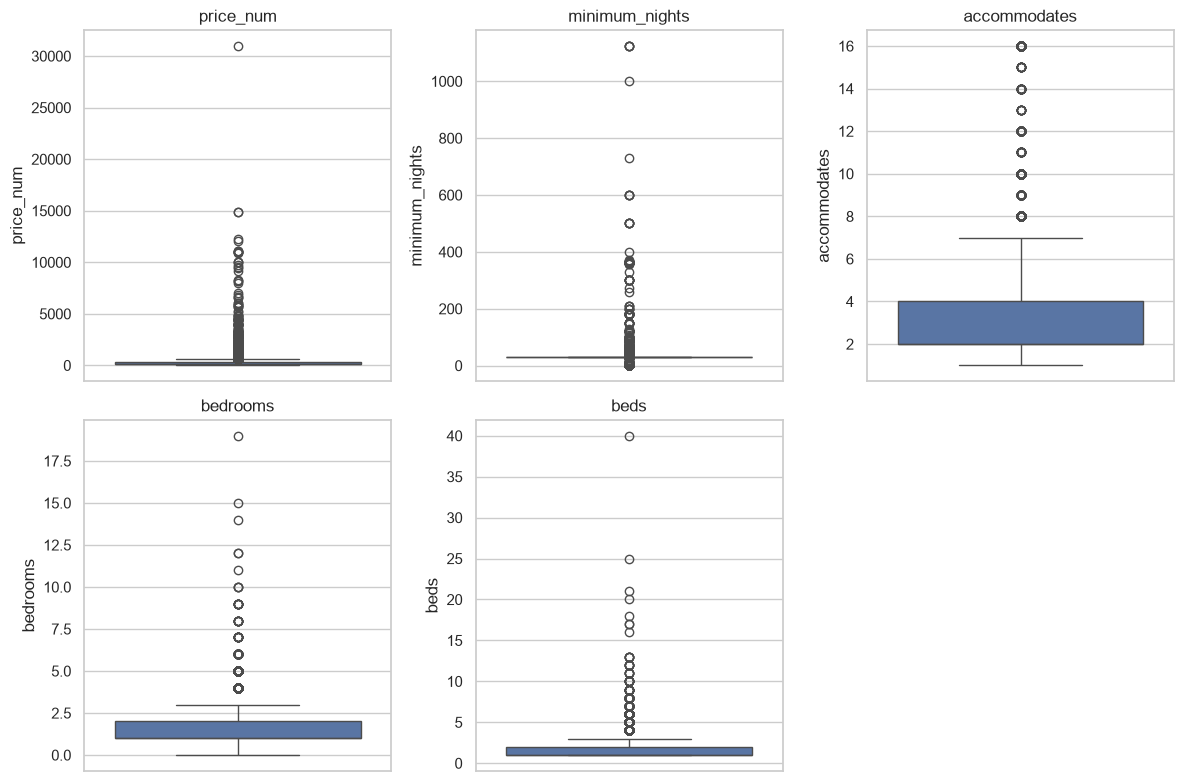

In [24]:
plot_boxplots(airbnb_df, numeric_cols_airbnb)


In [25]:
# Kiểm tra ràng buộc logic: accommodates phải >= bedrooms (thường không nhỏ hơn)
logic_violation_airbnb = airbnb_df[airbnb_df['accommodates'] < airbnb_df['bedrooms']]
print('Số listing vi phạm ràng buộc logic (accommodates < bedrooms):', len(logic_violation_airbnb))


Số listing vi phạm ràng buộc logic (accommodates < bedrooms): 392


### 2.5.3 Thêm / xóa / biến đổi thuộc tính

In [26]:
# Thêm đặc trưng dẫn xuất
airbnb_df['price_per_person'] = airbnb_df['price_num'] / airbnb_df['accommodates'].replace(0, np.nan)

# Ví dụ tách 1 vài tiện nghi phổ biến thành cột nhị phân (chuẩn bị cho luật kết hợp)
for amenity in ['Wifi', 'Kitchen', 'Air conditioning', 'Pool']:
    col_name = 'has_' + amenity.lower().replace(' ', '_')
    airbnb_df[col_name] = airbnb_df['amenities_list'].apply(lambda lst: amenity in lst)

airbnb_df[['price_num', 'price_per_person', 'has_wifi', 'has_kitchen', 'has_pool']].head()


,price_num,price_per_person,has_wifi,has_kitchen,has_pool
0,113.97,56.985,False,True,False
1,117.27,39.090,True,True,False
2,80.06,80.060,True,True,False
3,77.17,77.170,True,True,False
4,202.47,101.235,True,True,False


In [27]:
import os
os.makedirs(f'{PROCESSED_DIR}/airbnb', exist_ok=True)
airbnb_df.to_csv(f'{PROCESSED_DIR}/airbnb/airbnb_preprocessed.csv', index=False)
print('Đã lưu file tiền xử lý Bộ 2.')


Đã lưu file tiền xử lý Bộ 2.


---
# BỘ 3: US Accidents (2016–2023)

**Nguồn:** https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
**Quy mô kỳ vọng:** khuyến nghị lấy mẫu vài trăm nghìn dòng (bộ gốc 7,7 triệu), 46 cột
**Giấy phép:** CC BY-NC-SA 4.0 — chỉ dùng phi thương mại

## 3.1 Tải dữ liệu (khuyến nghị lấy mẫu / lọc theo 1–2 bang để dễ xử lý)

In [29]:
accidents_path = f'{RAW_DIR}/us_accidents/US_Accidents.csv'

# Gợi ý: đọc theo chunk và lọc bang để tránh quá tải bộ nhớ với file gốc rất lớn
accidents_df = pd.concat(
    chunk[chunk['State'].isin(['CA', 'TX'])]
    for chunk in pd.read_csv(accidents_path, chunksize=200_000)
)

# accidents_df = pd.read_csv(accidents_path)  # thay bằng cách đọc theo chunk nếu file quá lớn
print('Kích thước:', accidents_df.shape)
accidents_df.head()


Kích thước: (2324270, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
728,A-729,Source2,3,2016-06-21 10:34:40,2016-06-21 11:04:40,38.085300,-122.233017,NaN,NaN,0.0,Right hand shoulder blocked due to accident on...,Magazine St,Vallejo,Solano,CA,94591,US,US/Pacific,KAPC,2016-06-21 10:54:00,75.0,NaN,48.0,30.00,10.0,Variable,5.8,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
729,A-730,Source2,3,2016-06-21 10:30:16,2016-06-21 11:16:39,37.631813,-122.084167,NaN,NaN,0.0,Accident on I-880 Northbound at Exit 26 Tennys...,I-880 N,Hayward,Alameda,CA,94544,US,US/Pacific,KHWD,2016-06-21 10:54:00,75.0,NaN,48.0,30.06,10.0,WSW,4.6,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
730,A-731,Source2,2,2016-06-21 10:49:14,2016-06-21 11:19:14,37.896564,-122.070717,NaN,NaN,0.0,Right lane blocked due to accident on CA-24 We...,I-680 N,Walnut Creek,Contra Costa,CA,94595,US,US/Pacific,KCCR,2016-06-21 10:53:00,82.9,NaN,31.0,29.97,10.0,NNW,4.6,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
731,A-732,Source2,3,2016-06-21 10:41:42,2016-06-21 11:11:42,37.334255,-122.032471,NaN,NaN,0.0,#4 &amp; HOV lane blocked due to accident on I...,N De Anza Blvd,Cupertino,Santa Clara,CA,95014,US,US/Pacific,KNUQ,2016-06-21 10:56:00,75.9,NaN,48.0,30.04,10.0,NNE,4.6,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
732,A-733,Source2,2,2016-06-21 10:16:26,2016-06-21 11:04:16,37.250729,-121.910713,NaN,NaN,0.0,Right hand shoulder blocked due to accident on...,Norman Y Mineta Hwy,San Jose,Santa Clara,CA,95118,US,US/Pacific,KRHV,2016-06-21 09:50:00,75.2,NaN,41.0,30.06,10.0,Variable,5.8,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


## 3.2 Từ điển dữ liệu (tự động sinh)

In [30]:
accidents_dict = data_dictionary(accidents_df)
accidents_dict
# ✍️ TODO: bổ sung cột Ý nghĩa/Thang đo cho toàn bộ 46 thuộc tính khi nộp bài.


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du
0,ID,str,2324270,0.00,None,None,A-729
1,Source,str,3,0.00,None,None,Source2
2,Severity,int64,4,0.00,1,4,3
3,Start_Time,str,1912139,0.00,None,None,2016-06-21 10:34:40
4,End_Time,str,2105036,0.00,None,None,2016-06-21 11:04:40
5,Start_Lat,float64,692469,0.00,25.89521,42.00542,38.0853
6,Start_Lng,float64,687150,0.00,-124.374965,-93.519615,-122.233017
7,End_Lat,float64,445694,42.88,26.0107,42.144578,38.827194
8,End_Lng,float64,453824,42.88,-124.400248,-93.519751,-120.030632
9,Distance(mi),float64,13948,0.00,0.0,227.210007,0.0


## 3.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

✍️ **TODO (nhóm viết):** bối cảnh an toàn giao thông, liên hệ giữa thời tiết/hạ tầng/thời điểm và mức độ nghiêm trọng.

**Kiểm chứng nhanh bằng code:**

Severity
1      14517
2    1896785
3     392257
4      20711
Name: count, dtype: int64


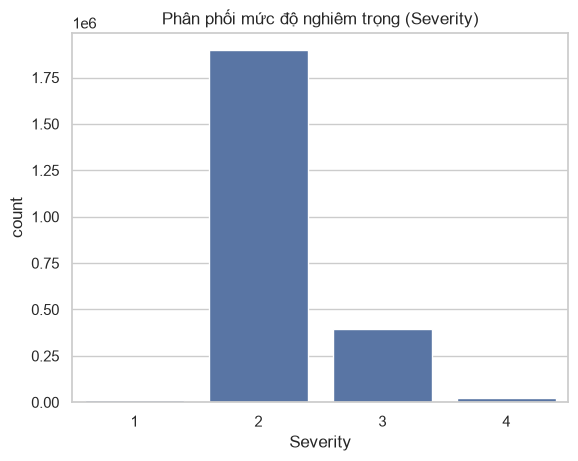

In [31]:
# Kiểm tra khả năng PHÂN LỚP: phân phối Severity (biến mục tiêu)
print(accidents_df['Severity'].value_counts(dropna=False).sort_index())
sns.countplot(x='Severity', data=accidents_df)
plt.title('Phân phối mức độ nghiêm trọng (Severity)')
plt.show()


In [32]:
# Kiểm tra khả năng LUẬT KẾT HỢP: tỉ lệ True của các cờ hạ tầng nhị phân
infra_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
              'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
              'Traffic_Signal', 'Turning_Loop']
infra_cols = [c for c in infra_cols if c in accidents_df.columns]
accidents_df[infra_cols].mean().sort_values(ascending=False)


Traffic_Signal     0.122396
Junction           0.093972
Crossing           0.071538
Stop               0.032957
Station            0.024468
Amenity            0.010272
Railway            0.010080
Give_Way           0.003848
No_Exit            0.001278
Traffic_Calming    0.000899
Bump               0.000548
Roundabout         0.000030
Turning_Loop       0.000000
dtype: float64

In [33]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng thời tiết số
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
weather_cols = [c for c in weather_cols if c in accidents_df.columns]
accidents_df[weather_cols].describe()


,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph)
count,2.269860e+06,2.266702e+06,2.274953e+06,2.120052e+06
mean,6.541115e+01,6.002287e+01,9.128725e+00,7.076854e+00
std,1.460244e+01,2.389906e+01,2.434611e+00,5.649575e+00
min,-4.000000e+01,1.000000e+00,0.000000e+00,0.000000e+00
25%,5.500000e+01,4.200000e+01,1.000000e+01,3.000000e+00
50%,6.440000e+01,6.200000e+01,1.000000e+01,6.900000e+00
75%,7.500000e+01,8.000000e+01,1.000000e+01,1.000000e+01
max,2.070000e+02,1.000000e+02,1.400000e+02,1.087000e+03


## 3.4 Kỹ thuật đề xuất trên Bộ 3

→ **Phân lớp** (dự đoán Severity) và **Luật kết hợp** (điều kiện thời tiết/hạ tầng đi cùng tai nạn nghiêm trọng).

## 3.5 Điều tra tiền xử lý (Mục 3.3)

### 3.5.1 Giá trị thiếu

In [34]:
missing_value_report(accidents_df, threshold=0).head(20)


,ti_le_thieu_%
End_Lng,42.88
End_Lat,42.88
Precipitation(in),34.23
Wind_Chill(F),31.71
Wind_Speed(mph),8.79
Humidity(%),2.48
Wind_Direction,2.41
Temperature(F),2.34
Visibility(mi),2.12
Weather_Condition,2.11


### 3.5.2 Nhiễu và ngoại lai

In [35]:
numeric_cols_accidents = [c for c in ['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)']
                          if c in accidents_df.columns]
outlier_iqr_report(accidents_df, numeric_cols_accidents)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,Temperature(F),55.0,75.000,20.000,25.0000,105.0000,7469,0.33
1,Visibility(mi),10.0,10.000,0.000,10.0000,10.0000,487032,21.41
2,Wind_Speed(mph),3.0,10.000,7.000,-7.5000,20.5000,36371,1.72
3,Distance(mi),0.0,0.359,0.359,-0.5385,0.8975,301987,12.99


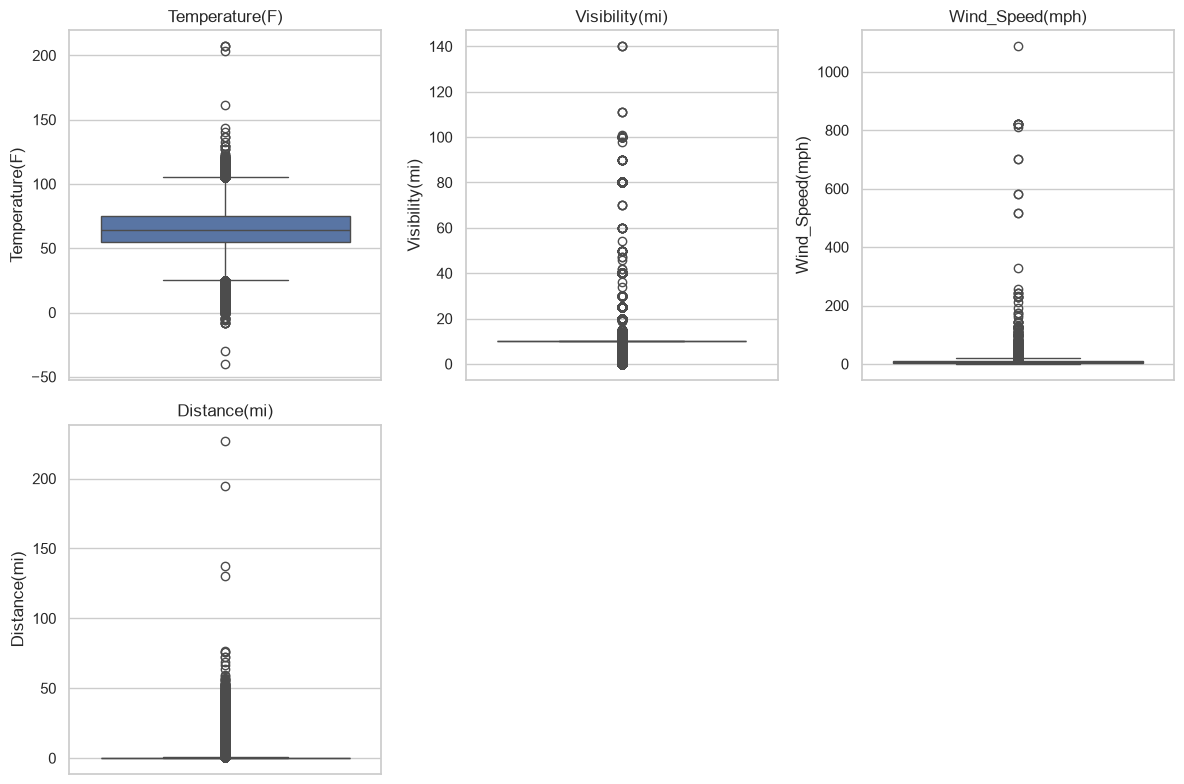

In [36]:
plot_boxplots(accidents_df, numeric_cols_accidents)


In [37]:
# Kiểm tra ràng buộc logic thời gian
accidents_df['Start_Time'] = pd.to_datetime(accidents_df['Start_Time'], errors='coerce')
accidents_df['End_Time'] = pd.to_datetime(accidents_df['End_Time'], errors='coerce')

logic_violation_acc = accidents_df[accidents_df['End_Time'] < accidents_df['Start_Time']]
print('Số vụ vi phạm ràng buộc logic thời gian (kết thúc trước khi bắt đầu):', len(logic_violation_acc))


Số vụ vi phạm ràng buộc logic thời gian (kết thúc trước khi bắt đầu): 0


### 3.5.3 Thêm / xóa / biến đổi thuộc tính

In [38]:
# Thêm đặc trưng dẫn xuất từ thời gian
accidents_df['Hour_of_Day'] = accidents_df['Start_Time'].dt.hour
accidents_df['Day_of_Week'] = accidents_df['Start_Time'].dt.day_name()
accidents_df['Is_Weekend'] = accidents_df['Start_Time'].dt.weekday >= 5

# Tổng số cờ hạ tầng = True trên mỗi vụ tai nạn
accidents_df['Infra_Feature_Count'] = accidents_df[infra_cols].sum(axis=1)

# Rời rạc hóa nhiệt độ thành khoảng (phục vụ luật kết hợp)
if 'Temperature(F)' in accidents_df.columns:
    accidents_df['Temperature_Bin'] = pd.cut(
        accidents_df['Temperature(F)'],
        bins=[-100, 32, 60, 80, 200],
        labels=['Rat_lanh', 'Lanh', 'Vua', 'Nong']
    )

accidents_df[['Hour_of_Day', 'Day_of_Week', 'Is_Weekend', 'Infra_Feature_Count']].head()


,Hour_of_Day,Day_of_Week,Is_Weekend,Infra_Feature_Count
728,10.0,Tuesday,False,0
729,10.0,Tuesday,False,0
730,10.0,Tuesday,False,0
731,10.0,Tuesday,False,0
732,10.0,Tuesday,False,0


In [39]:
import os
os.makedirs(f'{PROCESSED_DIR}/us_accidents', exist_ok=True)
accidents_df.to_csv(f'{PROCESSED_DIR}/us_accidents/accidents_preprocessed.csv', index=False)
print('Đã lưu file tiền xử lý Bộ 3.')


Đã lưu file tiền xử lý Bộ 3.


---
# Ma trận bộ dữ liệu × kỹ thuật (Mục 2.1)

| Bộ dữ liệu | Phân lớp | Luật kết hợp | Gom cụm |
|---|:---:|:---:|:---:|
| Bộ 1: Olist E-Commerce | ✓ (dự phòng) | ✓ (chọn) | ✓ (chọn) |
| Bộ 2: Inside Airbnb Listings | ✓ (chọn) | ✓ (dự phòng) | ✓ (chọn) |
| Bộ 3: US Accidents | ✓ (chọn) | ✓ (chọn) | ✓ (dự phòng) |

✅ Cả ba cột đều có ít nhất một dấu ✓ "chọn" — phủ đủ cả ba kỹ thuật theo yêu cầu Mục 2.

---

## Việc còn lại trước khi nộp Bài 1

- [ ] Tải dữ liệu thật vào `data/raw/` theo đúng cấu trúc thư mục đã dùng trong notebook.
- [ ] Chạy lại toàn bộ notebook, thay số liệu placeholder bằng số liệu thật.
- [ ] Hoàn thiện từ điển dữ liệu đầy đủ (thêm cột Ý nghĩa, Thang đo) cho cả 3 bộ.
- [ ] Viết phần "Điều tra tri thức lĩnh vực" bằng lời của nhóm ở các ô `✍️ TODO`.
- [ ] Diễn giải kết quả outlier/missing/logic-check bằng lời — quyết định giữ/loại/điền và lý do.
- [ ] Xuất báo cáo kỹ thuật `bao-cao-bai1.pdf` (3 đề xuất + ma trận + điều tra tiền xử lý) theo khung Mục 3.4.
